/tmp/ipykernel_1544176/3164830208.py:135: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, len(samples))


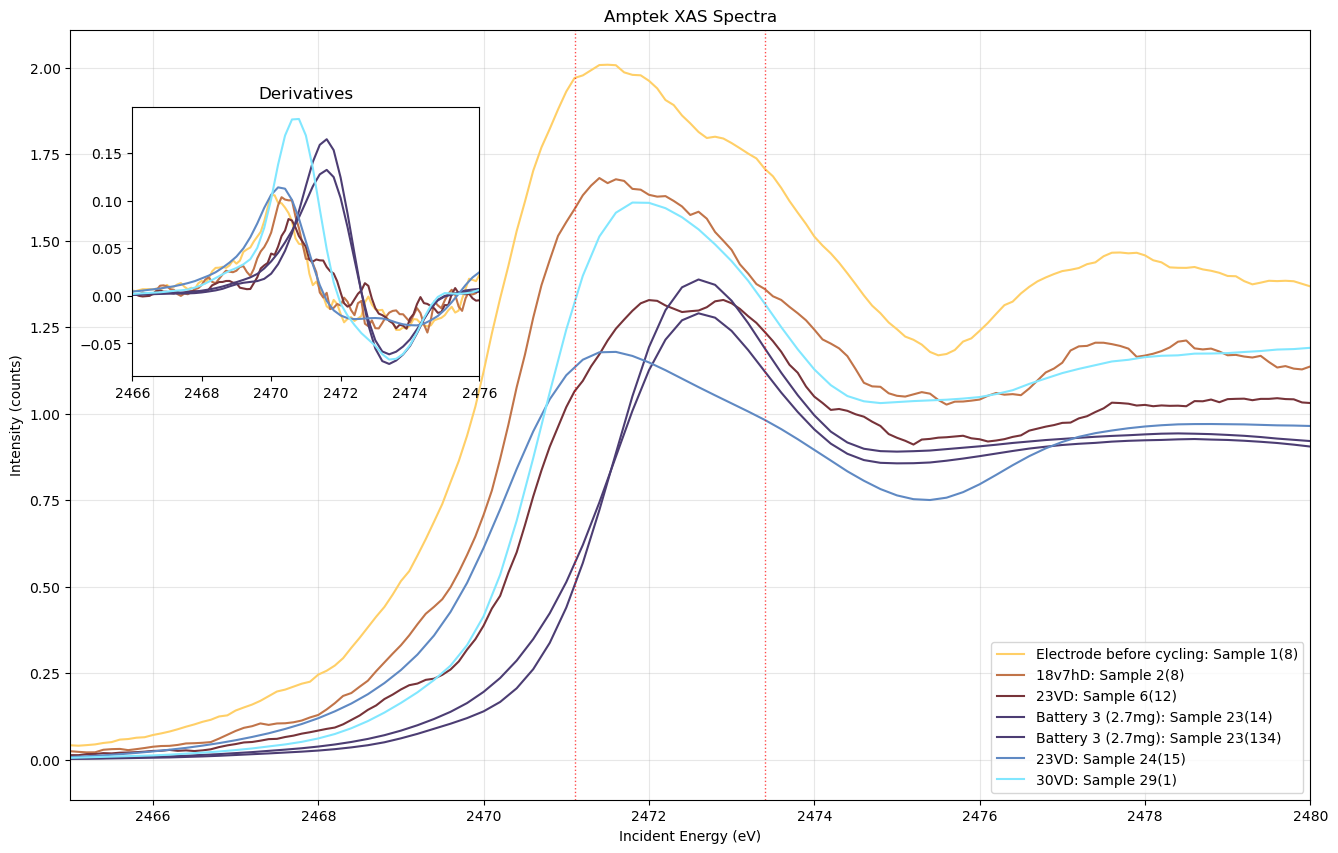

In [56]:
from dataclasses import dataclass, field
from enum import Enum, auto
from importlib.metadata import metadata
from pathlib import Path
from typing import List, Dict, Optional, Any

from scipy.signal import savgol_filter
import numpy as np
import os
import h5py
from dotenv import load_dotenv
import importlib
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec
from lmfit.models import PolynomialModel, GaussianModel, LinearModel, LorentzianModel, VoigtModel
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import logging
import warnings
__Analysis__ = "Analysis"

logging.basicConfig(level=logging.INFO, format='%(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__Analysis__)


def load_scans (sample_number: int,
                scans = dict['str', list],
                roi_id: Optional[int] = " ",
                kind: str = 'Amptek',
                smooth: Optional[int] = 1) -> Optional[pd.Series]:
    """ load specified scans from the h5 files that combine all scans of a sample. return df with all the data interpolated onto the same energy axis if needed"""

    path = f"Sample_{sample_number:04d}.h5"
    if not Path(path).exists():
        logger.error(f"Sample {sample_number:04d} does not exist")
        return None
    dfs = []
    with h5py.File(path, 'r') as f:
        sample_name = f["metadata"]["name"][()].decode("utf-8")

        for scan_number in scans[str(sample_number)]:
            scan_key = f"{scan_number:04d}"
            if scan_key not in f["scans"]:
                logger.error(f"Scan {scan_number:04d} does not exist in sample {sample_number:04d}")
                continue
            scan_grp = f["scans"][scan_key]


            if kind == 'Amptek':
                if "Amptek_XAS" not in scan_grp:
                    logger.error(f"Amptek_XAS not found in scan {scan_number:04d} of sample {sample_number:04d}")
                    continue
                data = scan_grp["Amptek_XAS"]["spectrum"][:]
                df = pd.DataFrame(data, columns=["incident_energy", "intensity","intensity_2", "I01", "I02"]),
                dfs.append(df)


    energy_ax = dfs[0][0]["incident_energy"]
    summed_intensity = np.zeros_like(energy_ax)

    for df in dfs:
        interpolated_intensity = np.interp(energy_ax, df[0]["incident_energy"], df[0]["intensity"])
        summed_intensity += interpolated_intensity


    if smooth and smooth > 1:
        smoothed = pd.Series(summed_intensity).rolling(window=smooth, center=True).mean().to_numpy()
        if smooth % 2 == 0:
            smooth += 1
        order = min (3, smooth - 1)  # Ensure polyorder is less than window_length
        smoothed = savgol_filter(summed_intensity, window_length=smooth, polyorder=order)#rolling mean for smoothing
    else:
        smoothed = summed_intensity

    df = pd.Series(data=smoothed, index=pd.Series(energy_ax, name="energy [eV]"), name=sample_name + ": Sample " + str(sample_number) + f"({scan_number})")
    return df


def nomalize_xas(df: pd.Series, flat = False, plot = False) -> pd.Series:
    #first find pre-edge line and subtract from entire spectrum
    if plot:
        fig,ax = plt.subplots(1, 1, figsize=(16, 10))
        ax.plot(df.index,df.values, color = 'black', label = "data")


    pre_edge = df[df.index < 2465]
    pre_line = np.polyfit(pre_edge.index, pre_edge.values, 1)
    pre_baseline = np.polyval(pre_line, df.index)
    pre_edge_normalized = df - pre_baseline
    if plot:
        ax.plot(df.index,pre_baseline, color = 'red', ls = '--', label = "pre-edge")

    #then fit a function to last part of spectra, evaluate it at e0 (max derivative) and normalize wit that

    post_edge = df[df.index > 2485]
    post_line = np.polyfit(post_edge.index, post_edge.values, 1)
    post_baseline = np.polyval(post_line, df.index)
    max_der= np.argmax(np.gradient(pre_edge_normalized))
    e0 = df.index[max_der]
    edge_step = np.polyval(post_line, e0) - np.polyval(pre_line, e0)
    normalized = pre_edge_normalized/edge_step

    norm_df = pd.Series(data=normalized, index=pd.Series(df.index, name="energy [eV]"), name=df.name)
    if plot:
        ax.plot(df.index,post_baseline, color = 'red', ls = '--', label = "post-edge")
        ax.axvline(e0, color='green', ls=':', label='E0')

    #flatten by fitting a quadratic function to the end and subtract that from the espectrum above e0

    if flat:
        post_edge = norm_df[norm_df.index > 2480] #maybe set both limits, idk why it doesn't normalize properly
        quadratic = np.polyfit(post_edge.index, post_edge.values, 1)
        baseline = np.polyval(quadratic, norm_df.index)


        flat = (norm_df - baseline) + baseline[max_der]
        flat.iloc[:max_der] = normalized.iloc[:max_der]


        if plot:
            ax.plot(df.index, (baseline*edge_step) , color='blue', ls='--', label="quad")
            ax.plot(post_edge.index,post_edge.values, linewidth = 10, alpha = 0.3)
        return  flat

    else:
        return norm_df


def plot_xas(samples: List[int], scans: Dict[str, List[int]], kind: str = 'Amptek', cmap_name='viridis'):
    cmap_name = 'managua'
    fig, ax = plt.subplots(1, 1, figsize=(16, 10))
    axin1 = ax.inset_axes([0.05, 0.55, 0.28, 0.35])

    cmap = cm.get_cmap(cmap_name, len(samples))
    norm = mcolors.Normalize(vmin=0, vmax=len(samples) - 1)
    for i, sample in enumerate(samples):
        temp_dict = {}
        #cmap = cm.get_cmap(cmap_name, len(scans[str(sample)]))
        #norm = mcolors.Normalize(vmin=0, vmax=len(scans[str(sample)]) - 1)

        for j, scan in enumerate(scans[str(sample)]):
            temp_dict[str(sample)] = [scan]
            df = load_scans(sample, temp_dict, kind=kind, smooth=10)
            df = nomalize_xas(df, plot=False, flat = True)
            data = df.to_numpy()
            if df is None:
                continue

            color = cmap(norm(i))


            ax.plot(df.index, data, label=df.name, color=color)
            axin1.plot(df.index, np.gradient(data), color=color)

    ax.set_xlabel("Incident Energy (eV)")
    ax.set_ylabel("Intensity (counts)")
    ax.set_title("Amptek XAS Spectra")
    ax.legend(loc = 'lower right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(2465,2480)

    battery_lines = [2471.1, 2473.4,2482.5]
    for line in battery_lines:
        ax.axvline(line, color='red', ls=':', alpha = 0.7, linewidth = 1)

    axin1.set_xlim(2466, 2476)
    axin1.set_title("Derivatives")








samples = [1,2,6,23,24,29]
scans = {'1':[8],
    '2':[8],
         '6': [12],
         '23':  [14,134],
         '24': [15],
         '29': [1]}
plot_xas(samples, scans)

In [87]:
#fit the XAS edge
df = load_scans(5, {'5':[6]},smooth=10)
df = load_scans(1, {'1':[8]},smooth=10)
df = nomalize_xas(df, plot=False, flat = True)

x = df.index
y = df.values

dy = np.gradient(y, x)

#model function
def fit_N_gaus(N, x, y, plot = True):
    "fit N gaussian fuction to the derivative of data"
    models = []
    for i in range(N):
        g = GaussianModel(prefix=f'g{i}_')
        models.append(g)
    model = models[0]
    for m in models[1:]:
        model += m
    params = model.make_params()
    gauss_start_values = [2469.2, 2470.0, 2471.0]

    for i in range(N):
        params[f'g{i}_center'].set(value=gauss_start_values[i], min=x[0], max=x[-1])
        params[f'g{i}_sigma'].set(value=0.1, min=0.001)
        params[f'g{i}_amplitude'].set(value=1, min=0)
    result = model.fit(y, params, x=x)
    if plot:
        fig, ax = plt.subplots(1, 1, figsize=(16, 10))
        ax.plot(x, y, label='Data', color='black')
        ax.plot(x, result.best_fit, label='Fit', color='red')
        for i in range(N):
            ax.plot(x, result.eval_components(x=x)[f'g{i}_'], label=f'Gaussian {i+1}')
        ax.legend()
        ax.set_xlabel("Energy [eV]")
        ax.set_ylabel("Intensity")
        ax.grid(True, alpha=0.3)

    #for now, return only th eosition and amplitude of peaks
    peaks = []
    for i in
    return result





#

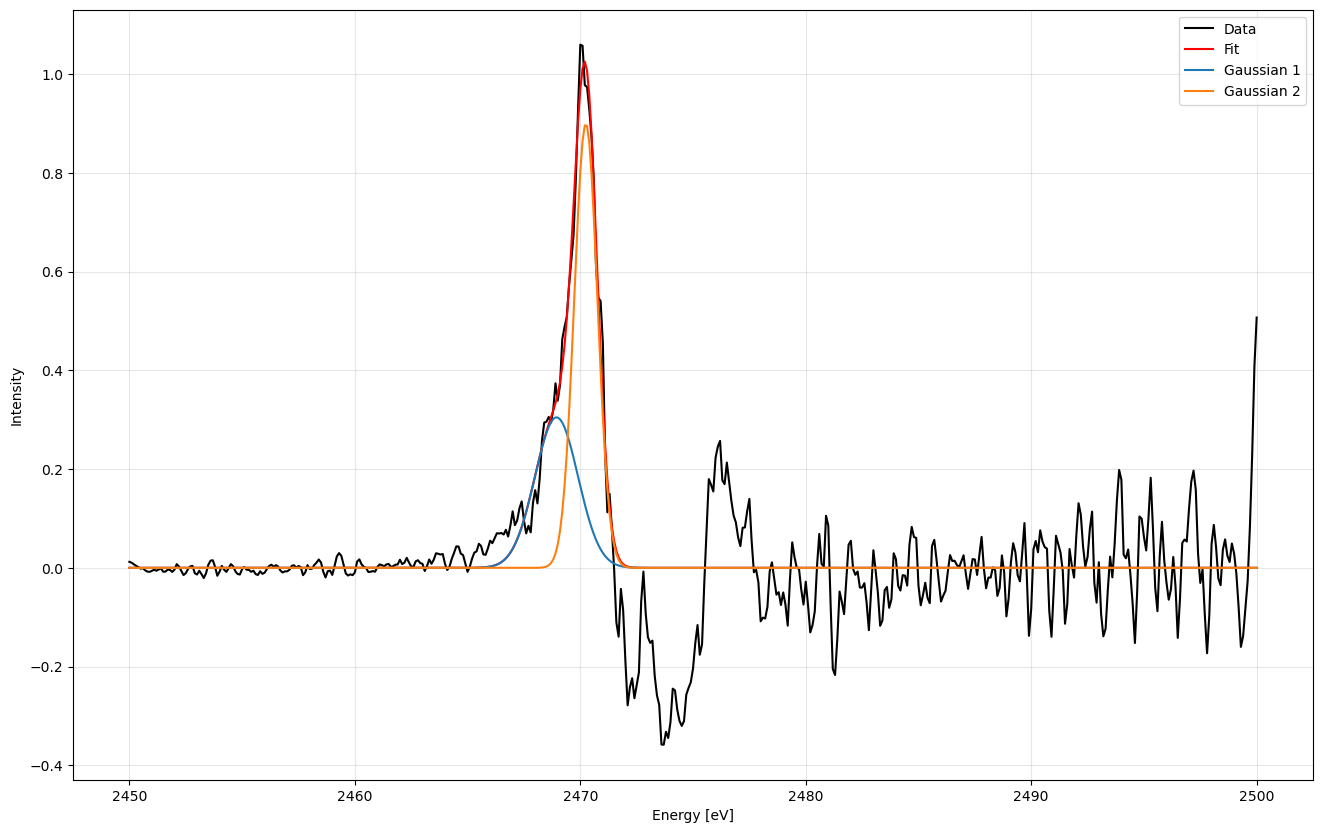

In [89]:
fit_N_gaus(2,x,dy,plot = True)#find position of first peak of the frivative